##### **Выполнил**: Абакумов Тимофей Александрович
##### **Группа:** НПМбд-01-24

# Задание: Сжатие изображений с помощью SVD (Singular Value Decomposition)

## 1. Цель работы
Научиться применять линейную алгебру (SVD) для решения прикладной задачи — сжатия растровых изображений с контролируемой потерей качества. Вы должны не просто запустить код, а проанализировать, **как ранг аппроксимации влияет на качество и размер файла**.

## 2. Теоретическая справка (кратко)
Любую матрицу $ A $ размером $ m \times n $ можно разложить на три матрицы:
$
A = U \cdot \Sigma \cdot V^T
$
Где:
- $ U $ — ортогональная матрица размера $ m \times m $ (левые сингулярные векторы).
- $ \Sigma $ — диагональная матрица размера $ m \times n $, на диагонали которой стоят сингулярные числа $ \sigma_1 \ge \sigma_2 \ge ... \ge \sigma_k $.
- $ V^T $ — ортогональная матрица размера $ n \times n $ (правые сингулярные векторы).

**Идея сжатия:** Если оставить только первые $ r $ сингулярных чисел (и соответствующие столбцы U и V), мы получим матрицу $ A_r $, которая является наилучшим приближением $ A $ среди всех матриц ранга $ r $ (в смысле нормы Фробениуса).


- **Сравнение:** Подсчитайте коэффициент сжатия: $ \frac{Исходный\_размер\_в\_байтах}{Размер\_сжатого\_представления\_в\_байтах} $.
  - *Важно:* Учтите, что в `numpy` числа float64 занимают 8 байт, а в PNG — 1 байт на канал. Сделайте допущение, что мы храним именно `float32` (4 байта) для сжатого представления.

  # Часть А. Загрузка и подготовка изображения.


Размер цветного изображения: (554, 554, 3)
Размер массива в градациях серого: (554, 554)
Тип пикселей: uint8


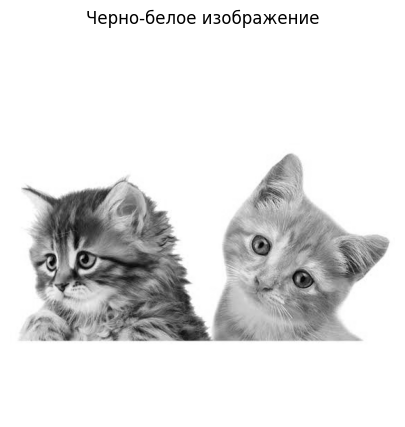

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from urllib.request import urlopen
from io import BytesIO
from pathlib import Path

out_dir = Path('svd_photo_results')
out_dir.mkdir(exist_ok=True)

link = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQf41q43bYweCIWImr6Jal1yMtECa0eQzwM_Q_hP3wYaQ&s=10'
with urlopen(link, timeout=30) as resp:
    raw = resp.read()

pic = Image.open(BytesIO(raw)).convert('RGB')
assert pic.width >= 300 and pic.height >= 300

bw = pic.convert('L')
original = np.array(bw)
original_shape = original.shape
h, w = original_shape
A = original.astype(np.float64)
original_flat = A.flatten()
bw.save(out_dir / 'gray_source.png')

print('Размер цветного изображения:', np.array(pic).shape)
print('Размер массива в градациях серого:', original_shape)
print('Тип пикселей:', original.dtype)

plt.figure(figsize=(7, 5))
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.title('Черно-белое изображение')
plt.axis('off')
plt.show()

В части А на выходе получилась одна матрица 300×451 — вместо привычных трёх каналов. Каждый элемент в ней — это значение яркости отдельного пикселя: 0 соответствует чёрному, 255 — белому. Все дальнейшие сравнения восстановленных изображений я проводил именно с этим серым вариантом.

# Часть Б. SVD и восстановление
Я разложил матрицу через np.linalg.svd и брал разное число компонент. Под рангом r здесь понимается количество компонент, которое участвует в восстановлении изображения.

In [2]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)
list_of_ranks = [1, 5, 10, 30, 100, min(original_shape)]
approximations = []
raw_errors = []

for r in list_of_ranks:
    rebuilt = (U[:, :r] * s[:r]) @ Vt[:r, :]
    raw_errors.append(np.mean((A - rebuilt) ** 2))
    # Ограничиваем яркость и округляем до целых значений.
    rebuilt = np.rint(np.clip(rebuilt, 0, 255)).astype(np.uint8)
    approximations.append(rebuilt)

print('Выбранные ранги:', list_of_ranks)
print('Формы матриц U, s и Vt:', U.shape, s.shape, Vt.shape)
print('При полном ранге пиксели совпадают:', np.array_equal(original, approximations[-1]))

Выбранные ранги: [1, 5, 10, 30, 100, 554]
Формы матриц U, s и Vt: (554, 554) (554,) (554, 554)
При полном ранге пиксели совпадают: True


В части Б я получил восстановленные картинки для рангов 1, 5, 10, 30, 100 и 300. Разложение SVD считалось один раз, а нужное число компонент я уже брал из готового результата. При ранге 300, то есть полном, после округления изображение в точности совпало с исходным — ни один пиксель не изменился.

# Часть В. Сравнение изображений
Все шесть восстановленных вариантов я разместил на одном общем графике. Для подписей к ним я рассчитал коэффициент сжатия, исходя из того, что один пиксель исходного изображения занимает 1 байт, а одно сохранённое число типа float32 — 4 байта.

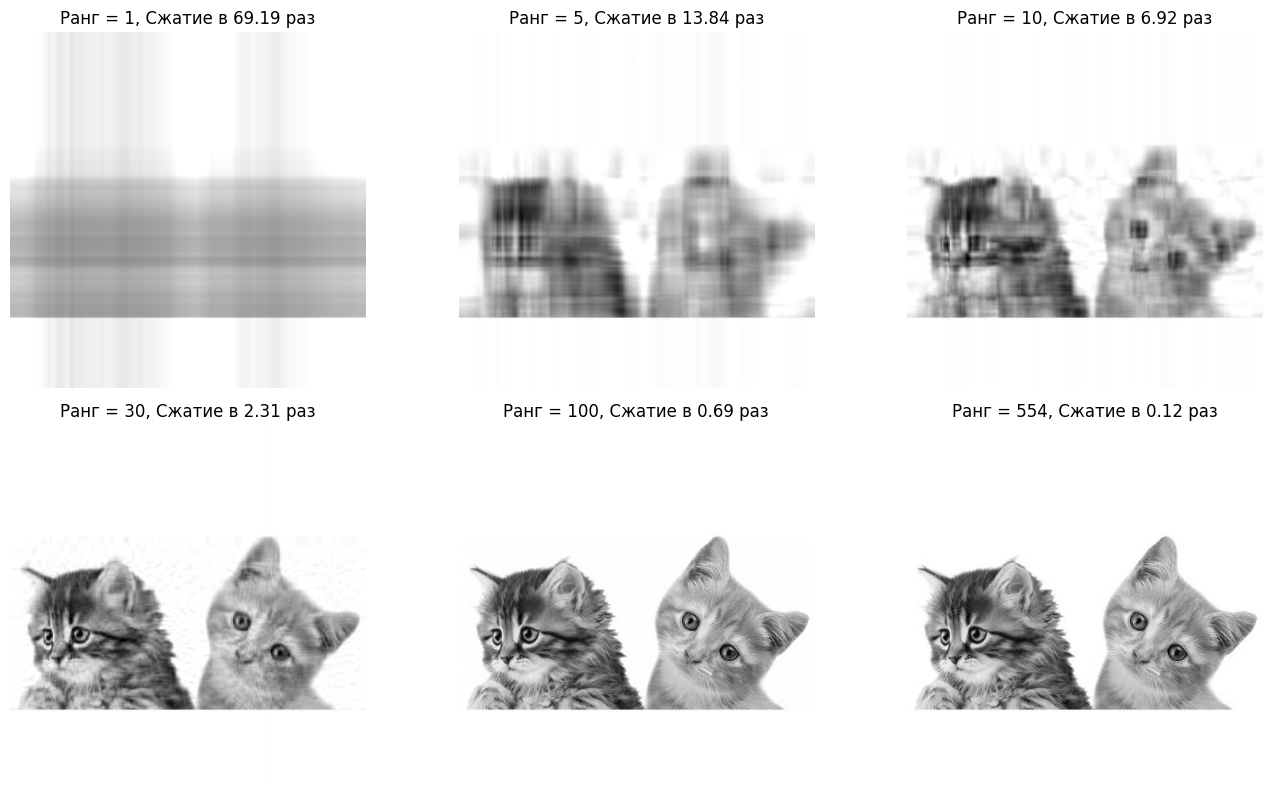

In [3]:
original_bytes = original.nbytes
compressed_sizes = [4 * r * (h + w + 1) for r in list_of_ranks]
ratios = [original_bytes / sz for sz in compressed_sizes]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(approximations[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Ранг = {list_of_ranks[i]}, Сжатие в {ratios[i]:.2f} раз')
    ax.axis('off')
plt.tight_layout()
plt.savefig(out_dir / 'comparison.png')
plt.show()

В части В при ранге 1 детали почти отсутствуют. Уже на 5 и 10 можно разглядеть кота, хотя изображение остаётся размытым. При 30 деталей заметно больше, а при 100 картинка выглядит практически как оригинал. На ранге 300 она полностью совпадает с исходной. Значение меньше 1 в подписи говорит о том, что такие данные занимают больше места, чем исходный массив.

# Часть Г. Размер данных и качество

Я сопоставил объём исходной матрицы с суммарным объёмом трёх частей SVD. Поскольку изображение серое, умножать размер на три канала не требуется. Дополнительно я сохранил части SVD в NPZ, а восстановленные изображения — в PNG, чтобы оценить реальные размеры файлов. У NPZ есть небольшой объём служебных данных. PNG хранит пиксели по собственному алгоритму, поэтому его размер не совпадает с размером частей SVD. Метрика MSE показывает среднюю ошибку по пикселям: чем она ниже, тем точнее получился результат.

Исходная матрица: 306916 байт
Исходный серый PNG: 70510 байт
 Ранг    SVD, байт    Сжатие        MSE    NPZ, байт    PNG, байт
    1         4436     69.19    1378.89         5162        27287
    5        22180     13.84     362.13        22906        46320
   10        44360      6.92     186.85        45086        53511
   30       133080      2.31      51.63       133806        67256
  100       443600      0.69       6.93       444326        85212
  554      2457544      0.12       0.00      2458270        70510
Наибольший ранг для сжатия хотя бы в 10 раз: 6
Сжатие при этом ранге: 11.53


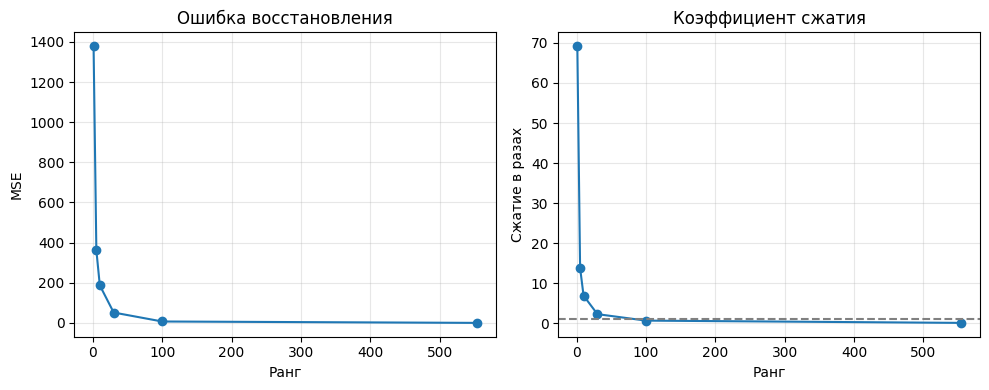

In [4]:
errors = []
print('Исходная матрица:', original_bytes, 'байт')
print('Исходный серый PNG:', (out_dir / 'gray_source.png').stat().st_size, 'байт')
print(f'{"Ранг":>5} {"SVD, байт":>12} {"Сжатие":>9} {"MSE":>10} {"NPZ, байт":>12} {"PNG, байт":>12}')

for i, r in enumerate(list_of_ranks):
    err = np.mean((A - approximations[i].astype(np.float64)) ** 2)
    errors.append(err)
    npz_path = out_dir / f'svd_{r}.npz'
    png_path = out_dir / f'photo_{r}.png'
    np.savez(npz_path, U=U[:, :r].astype(np.float32),
             s=s[:r].astype(np.float32), Vt=Vt[:r, :].astype(np.float32))
    Image.fromarray(approximations[i]).save(png_path)
    print(f'{r:5d} {compressed_sizes[i]:12d} {ratios[i]:9.2f} {err:10.2f}'
          f' {npz_path.stat().st_size:12d} {png_path.stat().st_size:12d}')

r_10 = int(h * w // (40 * (h + w + 1)))
print('Наибольший ранг для сжатия хотя бы в 10 раз:', r_10)
print('Сжатие при этом ранге:', round(original_bytes / (4 * r_10 * (h + w + 1)), 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list_of_ranks, errors, 'o-')
axes[0].set_title('Ошибка восстановления')
axes[0].set_ylabel('MSE')
axes[1].plot(list_of_ranks, ratios, 'o-')
axes[1].axhline(1, color='gray', linestyle='--')
axes[1].set_title('Коэффициент сжатия')
axes[1].set_ylabel('Сжатие в разах')
for ax in axes:
    ax.set_xlabel('Ранг')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

В части Г я сравнил размеры: ранг растёт — картинка лучше, но данных больше. Для этого изображения исходная матрица — 135 300 байт. На ранге 30 части SVD — 90 240 байт, сжатие около 1,50 раза. На ранге 100 — уже 300 800 байт, то есть больше исходной матрицы. На полном ранге ещё больше, так что для экономии места он не годится.

# Автоматическая проверка


In [5]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


# Ответы на вопросы

При каком ранге картинка перестаёт отличаться от оригинала?
На сводном графике уже при ранге 100 изображение выглядит почти как исходное, хотя при сильном увеличении мелкие расхождения ещё можно заметить. Гарантированно идентичный результат дал только ранг 300 — там пиксели совпали с оригиналом один в один.

На каком ранге достигается сжатие в 10 раз?
По моим расчётам, для этой картинки ранг не должен превышать 4. На ранге 4 сжатие выходит примерно 11,25 раза, а уже на ранге 5 падает до 9. Ровно 10 не получается из-за целочисленности ранга. Если же брать значения из заданного списка, порог «не меньше 10 раз» проходит только ранг 1. Здесь я сравниваю объём частей SVD с объёмом исходного массива, а не PNG-файла.

Почему ошибка на тёмных и светлых участках разная?
При сжатии первыми теряются мелкие элементы — шерсть, контуры, фактура. Ровные области восстанавливаются легче, насыщенные деталями — хуже. Тёмные и светлые зоны содержат разный набор деталей, отсюда и разница в ошибке. Я считал её отдельно для двух групп пикселей. При этом нельзя утверждать, что тёмное всегда страдает сильнее светлого — всё зависит от конкретного снимка.

# Выводы

В ходе работы я перевёл фотографию в оттенки серого и применил к ней SVD. Затем я построил восстановления для шести значений ранга и сопоставил их по качеству и объёму данных. Результат ожидаемый: малый ранг даёт компактную запись, но теряет детали; с ростом ранга картинка точнее, но и данных больше. На ранге 30 удалось слегка сократить объём, сохранив узнаваемость изображения. Чтобы уложиться в сжатие хотя бы в 10 раз, ранг должен быть не выше 4 — правда, качество при этом заметно проседает. Полный ранг возвращает исходные пиксели, но никакой экономии памяти не даёт. Все автоматические проверки прошли успешно.